<a href="https://colab.research.google.com/github/QuynhAnh2101/BAI-TAP/blob/main/BTVN_BU%E1%BB%94I_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
m = folium.Map(location=[10.7610532, 106.668358], zoom_start=13)
folium.Marker([10.7610532, 106.668358], popup="Đại học kinh tế TP.HCM-Cơ sở B", tooltip="Click vào").add_to(group_truong)

group_truong = folium.FeatureGroup(name='Trường học').add_to(m)
group_benhvien = folium.FeatureGroup(name='Bệnh viện').add_to(m)
group_muasamhanhchinh = folium.FeatureGroup(name='Mua sắm & Hành chính').add_to(m)

folium.Map(location=[10.7705748, 106.6699228], zoom_start=13)
folium.Marker([10.7705748, 106.6699228], popup="Vạn Hạnh Mall", tooltip="Click vào").add_to(group_muasamhanhchinh)

folium.Map(location=[10.7691262, 106.6710121], zoom_start=13)
folium.Marker([110.7691262, 106.6710121], popup="Bệnh viện nhi đồng 1", tooltip="Click vào").add_to(group_benhvien)

folium.Map(location=[10.7550025, 106.6705345], zoom_start=13)
folium.Marker([10.7550025, 106.6705345], popup="Bệnh viện Nguyễn Tri Phương", tooltip="Click vào").add_to(group_benhvien)

folium.Map(location=[10.7601417, 106.6661562], zoom_start=13)
folium.Marker([10.7601417, 106.6661562], popup="Ủy ban nhân dân Phường 5, Quận 10", tooltip="Click vào").add_to(group_muasamhanhchinh)

folium.Map(location=[10.756251, 106.6630621], zoom_start=13)
folium.Marker([10.756251, 106.6630621], popup="Hùng Vương Plaza", tooltip="Click vào").add_to(group_muasamhanhchinh)

folium.LayerControl().add_to(m)
m

In [ ]:
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import folium
geolocator = Nominatim(user_agent="geoapi")
addresses = [
    "Ben Thanh Market, Ho Chi Minh City",
    "Tan Son Nhat Airport, Ho Chi Minh City",
    "Saigon Notre-Dame Cathedral, Ho Chi Minh City",
    "Independence Palace, Ho Chi Minh City",
    "Landmark 81, Ho Chi Minh City",
    "Bitexco Tower, Ho Chi Minh City",
    "Saigon Zoo, Ho Chi Minh City",
    "Pham Ngu Lao Street, Ho Chi Minh City",
    "Vincom Center Dong Khoi, Ho Chi Minh City",
    "Saigon Central Post Office, Ho Chi Minh City"
]
center_address = "University of Economics Ho Chi Minh City"
center_location = geolocator.geocode(center_address)
center_coords = (center_location.latitude, center_location.longitude)
m = folium.Map(location=center_coords, zoom_start=13)
folium.Marker(center_coords, popup="Trung tâm",
              icon=folium.Icon(color="red")).add_to(m)
for addr in addresses:
    location = geolocator.geocode(addr)
    if location is None:
        print(f"Không tìm thấy: {addr}")
        continue
    coords = (location.latitude, location.longitude)
    dist = geodesic(center_coords, coords).km
    print(f"{addr}: {dist:.2f} km")
    folium.Marker(
        coords,
        popup=f"{addr}\n{dist:.2f} km",
        icon=folium.Icon(color="blue")
    ).add_to(m)
    folium.PolyLine([center_coords, coords], color="green").add_to(m)
m

Ben Thanh Market, Ho Chi Minh City: 1.21 km
Tan Son Nhat Airport, Ho Chi Minh City: 5.73 km
Saigon Notre-Dame Cathedral, Ho Chi Minh City: 0.58 km
Independence Palace, Ho Chi Minh City: 0.66 km
Landmark 81, Ho Chi Minh City: 3.34 km
Bitexco Tower, Ho Chi Minh City: 1.62 km
Saigon Zoo, Ho Chi Minh City: 1.36 km
Pham Ngu Lao Street, Ho Chi Minh City: 1.87 km
Vincom Center Dong Khoi, Ho Chi Minh City: 0.94 km
Saigon Central Post Office, Ho Chi Minh City: 0.65 km


In [ ]:
from folium.plugins import HeatMap
import folium
donhang = [
    [10.775, 106.700],
    [10.780, 106.690],
    [10.770, 106.710]
]
m = folium.Map(location=[10.775, 106.700], zoom_start=13)
HeatMap(donhang).add_to(m)
m

In [ ]:
import folium
import pandas as pd
df = pd.read_excel("/23.4.xlsx")
geo_data = "/hcm_districts.geojson"
m = folium.Map(location=[10.776, 106.700], zoom_start=12)
folium.Choropleth(
    geo_data=geo_data,
    data=df,
    columns=["Tinh", "Doanh thu(Trieu dong)"],
    key_on="feature.properties.name",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Doanh thu (triệu đồng)"
).add_to(m)
m

In [ ]:
import folium
center = [10.776, 106.700]
m = folium.Map(location=center, zoom_start=13)
for r in [3000, 5000, 10000]:
    folium.Circle(center, radius=r, fill=True).add_to(m)
m

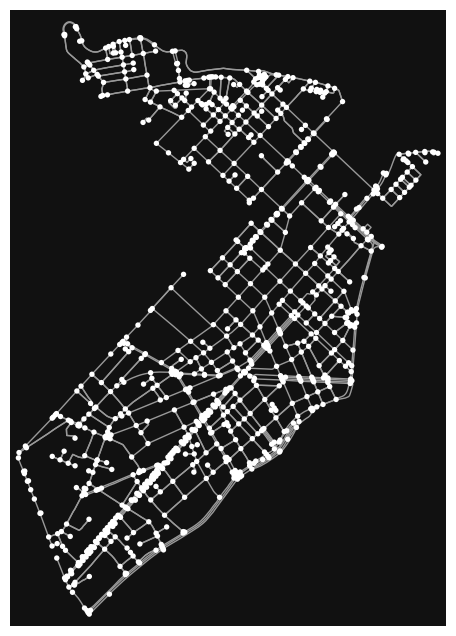

Số nút giao thông: 985
Chiều dài đường trung bình (m): 79.29769867694213


In [ ]:
!pip install osmnx
import osmnx as ox
import osmnx as ox
G = ox.graph_from_place("District 1, Ho Chi Minh City, Vietnam", network_type='drive')

ox.plot_graph(G)
print("Số nút giao thông:", len(G.nodes))
edges = ox.graph_to_gdfs(G, nodes=False)
print("Chiều dài đường trung bình (m):", edges["length"].mean())



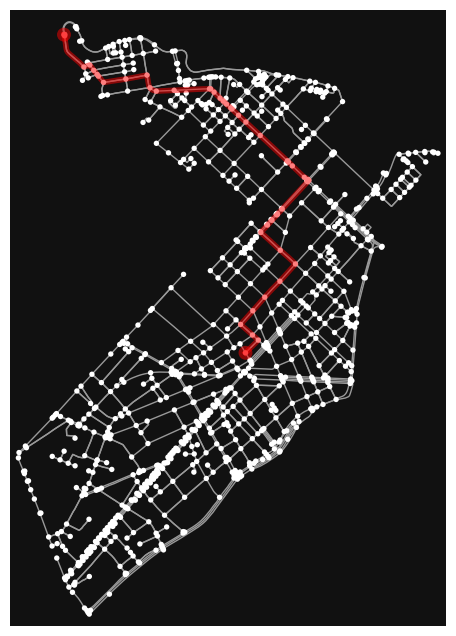

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
import osmnx as ox
import networkx as nx
G = ox.graph_from_place("District 1, Ho Chi Minh City, Vietnam", network_type='drive')

orig = ox.geocode("Ben Thanh Market, Ho Chi Minh City, Vietnam")
dest = ox.geocode("Tan Son Nhat Airport, Ho Chi Minh City, Vietnam")
orig_node = ox.distance.nearest_nodes(G, orig[1], orig[0])
dest_node = ox.distance.nearest_nodes(G, dest[1], dest[0])
route = nx.shortest_path(G, orig_node, dest_node, weight='length')
ox.plot_graph_route(G, route)

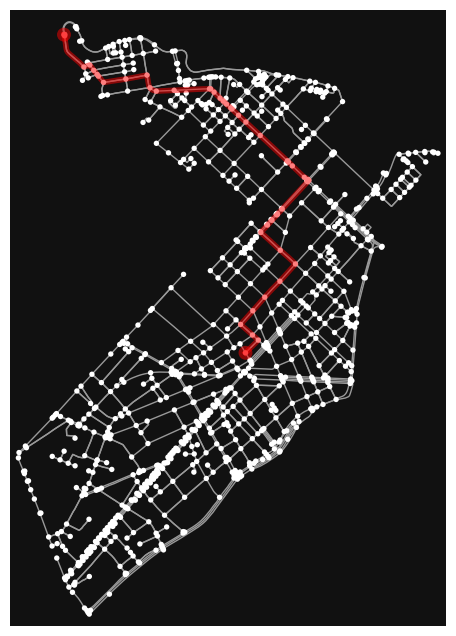

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
import osmnx as ox
import networkx as nx
G = ox.graph_from_place("District 1, Ho Chi Minh City, Vietnam", network_type='drive')

orig = ox.geocode("Ben Thanh Market, Ho Chi Minh City, Vietnam")
dest = ox.geocode("Tan Son Nhat Airport, Ho Chi Minh City, Vietnam")
orig_node = ox.distance.nearest_nodes(G, orig[1], orig[0])
dest_node = ox.distance.nearest_nodes(G, dest[1], dest[0])
route = nx.astar_path(G, orig_node, dest_node, weight='length')
ox.plot_graph_route(G, route)

In [ ]:
from geopy.distance import distance
import folium
driver = (10.770, 106.690)
customers = {
    "A": (10.775, 106.700),
    "B": (10.760, 106.680),
    "C": (10.772, 106.695)
}
nearest = min(customers.items(), key=lambda x: distance(driver, x[1]).km)
m = folium.Map(location=driver, zoom_start=13)
folium.Marker(driver, popup="Driver", icon=folium.Icon(color="red")).add_to(m)
for name, coord in customers.items():
    d = distance(driver, coord).km
    folium.Marker(
        coord,
        popup=f"{name}: {d:.2f} km",
        icon=folium.Icon(color="blue")
    ).add_to(m)
    color = "green" if name == nearest[0] else "red"
    folium.PolyLine(
        [driver, coord],
        color=color,
        weight=5 if name == nearest[0] else 2
    ).add_to(m)
m

In [ ]:
from geopy.distance import distance
import folium
drivers = {
    "D1": (10.770, 106.690),
    "D2": (10.760, 106.680)
}
customers = {
    "C1": (10.775, 106.700),
    "C2": (10.762, 106.685),
    "C3": (10.768, 106.695)
}
m = folium.Map(location=[10.770, 106.690], zoom_start=13)
for c_name, c_coord in customers.items():
    folium.Marker(
        c_coord,
        popup=f"{c_name}",
        icon=folium.Icon(color="gray")
    ).add_to(m)
assigned = set()
for d_name, d_coord in drivers.items():
    nearest = None
    min_dist = float("inf")
    for c_name, c_coord in customers.items():
        if c_name in assigned:
            continue
        d = distance(d_coord, c_coord).km
        if d < min_dist:
            min_dist = d
            nearest = (c_name, c_coord)
    assigned.add(nearest[0])
    folium.Marker(
        d_coord,
        popup=f"{d_name}",
        icon=folium.Icon(color="red")
    ).add_to(m)
    folium.Marker(
        nearest[1],
        popup=f"{nearest[0]} ({min_dist:.2f} km)",
        icon=folium.Icon(color="blue")
    ).add_to(m)
    folium.PolyLine(
        [d_coord, nearest[1]],
        color="green",
        weight=5
    ).add_to(m)
m

In [ ]:
import folium
roads = [
    {"name": "A", "coord": (10.770, 106.690), "traffic": 80},
    {"name": "B", "coord": (10.775, 106.700), "traffic": 60},
    {"name": "C", "coord": (10.760, 106.680), "traffic": 30},
    {"name": "D", "coord": (10.765, 106.695), "traffic": 90}
]
def risk_level(traffic):
    if traffic > 70:
        return "High", "red"
    elif traffic > 40:
        return "Medium", "orange"
    else:
        return "Low", "green"
m = folium.Map(location=[10.770, 106.690], zoom_start=13)
for r in roads:
    level, color = risk_level(r["traffic"])
    folium.CircleMarker(
        location=r["coord"],
        radius=10,
        color=color,
        fill=True,
        fill_color=color,
        popup=f"{r['name']} - {level}"
    ).add_to(m)
main_route = [
    (10.770, 106.690),
    (10.765, 106.695),
    (10.775, 106.700)
]

folium.PolyLine(main_route, color="red", weight=5, popup="Đường tắc").add_to(m)
alt_route = [
    (10.770, 106.690),
    (10.760, 106.680),
    (10.775, 106.700)
]
folium.PolyLine(alt_route, color="blue", weight=5, popup="Đường đề xuất").add_to(m)
m

In [ ]:
import pandas as pd
import folium
from sklearn.linear_model import LinearRegression
data = {
    "Area": ["A","A","A","B","B","B","C","C","C"],
    "Hour": [8, 12, 18, 8, 12, 18, 8, 12, 18],
    "Demand": [50, 80, 120, 30, 60, 90, 20, 40, 70]
}
df = pd.DataFrame(data)
df["Area_code"] = df["Area"].map({"A":0, "B":1, "C":2})
X = df[["Area_code", "Hour"]]
y = df["Demand"]
model = LinearRegression()
model.fit(X, y)
future = pd.DataFrame({
    "Area_code": [0,1,2],
    "Hour": [20,20,20]
})
pred = model.predict(future)
coords = {
    "A": (10.770, 106.690),
    "B": (10.760, 106.680),
    "C": (10.775, 106.700)
}
m = folium.Map(location=[10.770, 106.690], zoom_start=13)
areas = ["A","B","C"]
for i, area in enumerate(areas):
    demand = pred[i]
    if demand > 100:
        color = "red"
    elif demand > 60:
        color = "orange"
    else:
        color = "green"
    folium.CircleMarker(
        location=coords[area],
        radius=10,
        color=color,
        fill=True,
        fill_color=color,
        popup=f"{area}: {demand:.0f}"
    ).add_to(m)
m

In [ ]:
from geopy.distance import distance
import folium
depots = {
    "D1": (10.770, 106.690),
    "D2": (10.760, 106.680)
}
customers = {
    "C1": (10.775, 106.700),
    "C2": (10.762, 106.685),
    "C3": (10.768, 106.695),
    "C4": (10.758, 106.678)
}
def total_distance(route):
    dist = 0
    for i in range(len(route)-1):
        dist += distance(route[i], route[i+1]).km
    return dist
clusters = {d: [] for d in depots}
for c_name, c_coord in customers.items():
    nearest_depot = min(depots.items(), key=lambda x: distance(c_coord, x[1]).km)
    clusters[nearest_depot[0]].append((c_name, c_coord))
routes_opt = {}
for d_name, d_coord in depots.items():
    points = clusters[d_name][:]
    route = [d_coord]
    current = d_coord
    while points:
        nearest = min(points, key=lambda x: distance(current, x[1]).km)
        route.append(nearest[1])
        current = nearest[1]
        points.remove(nearest)
    routes_opt[d_name] = route
routes_naive = {}
for d_name, d_coord in depots.items():
    route = [d_coord] + [c[1] for c in clusters[d_name]]
    routes_naive[d_name] = route
opt_total = sum(total_distance(r) for r in routes_opt.values())
naive_total = sum(total_distance(r) for r in routes_naive.values())
print("Tổng quãng đường tối ưu:", opt_total)
print("Tổng quãng đường không tối ưu:", naive_total)
m = folium.Map(location=[10.770, 106.690], zoom_start=13)
for d_name, coord in depots.items():
    folium.Marker(coord, popup=d_name, icon=folium.Icon(color="red")).add_to(m)
for c_name, coord in customers.items():
    folium.Marker(coord, popup=c_name, icon=folium.Icon(color="blue")).add_to(m)
for route in routes_opt.values():
    folium.PolyLine(route, color="green", weight=5).add_to(m)
for route in routes_naive.values():
    folium.PolyLine(route, color="red", weight=2).add_to(m)
m

Tổng quãng đường tối ưu: 2.733236774941018
Tổng quãng đường không tối ưu: 3.64772516361514


In [ ]:
import folium
from folium.plugins import MarkerCluster, Fullscreen, MeasureControl
import pandas as pd
dc_coords = (10.7758, 106.7009)
data = {
    'ID': ['C001', 'C002', 'C003', 'C004', 'C005'],
    'Name': ['Siêu thị A', 'Cửa hàng B', 'Đại lý C', 'Kho vệ tinh D', 'Trung tâm E'],
    'Lat': [10.7626, 10.7850, 10.8000, 10.7500, 10.8200],
    'Lon': [10.6602, 10.6950, 10.7500, 10.7200, 10.7000],
    'Volume': [500, 200, 800, 1200, 450]
}
df = pd.DataFrame(data)
m = folium.Map(location=dc_coords, zoom_start=12, tiles='cartodbpositron')
Fullscreen().add_to(m)
MeasureControl().add_to(m)
fg_dc = folium.FeatureGroup(name="Kho Tổng & Vùng Phục Vụ")
folium.Marker(
    location=dc_coords,
    popup="<b>KHO TỔNG TRUNG TÂM</b>",
    icon=folium.Icon(color="red", icon="home", prefix='fa')
).add_to(fg_dc)
folium.Circle(
    location=dc_coords,
    radius=5000,
    color='red',
    fill=True,
    fill_opacity=0.1,
    tooltip="Vùng phục vụ 5km"
).add_to(fg_dc)
fg_dc.add_to(m)
fg_customers = folium.FeatureGroup(name="Mạng Lưới Khách Hàng")
marker_cluster = MarkerCluster().add_to(fg_customers)

for _, row in df.iterrows():
    if row['Volume'] >= 1000:
        color_node = 'darkred'
    elif row['Volume'] >= 500:
        color_node = 'orange'
    else:
        color_node = 'green'
    folium.Marker(
        location=[row['Lat'], row['Lon']],
        popup=f"<b>{row['Name']}</b><br>Sản lượng: {row['Volume']} kiện/ngày",
        icon=folium.Icon(color=color_node, icon="shopping-cart", prefix='fa')
    ).add_to(marker_cluster)
fg_customers.add_to(m)
fg_routes = folium.FeatureGroup(name="Tuyến Vận Tải")
route_points = [dc_coords, (10.7500, 10.7200)]
folium.PolyLine(
    locations=route_points,
    color="blue",
    weight=5,
    opacity=0.6,
    dash_array='10'
).add_to(fg_routes)
fg_routes.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
m

In [ ]:
import folium
from folium.plugins import TimestampedGeoJson, AntPath
import numpy as np
from datetime import datetime, timedelta
origin = [10.7758, 106.7009]
destinations = [
    {"id": "Xe_Giao_Hang_01", "coords": [10.7626, 106.6602], "color": "#1f77b4"},
    {"id": "Xe_Giao_Hang_02", "coords": [10.8000, 106.7500], "color": "#d62728"},
    {"id": "Xe_Giao_Hang_03", "coords": [10.7500, 106.7200], "color": "#2ca02c"}
]
start_time = datetime.now().replace(hour=8, minute=0, second=0, microsecond=0)
def create_route_points(start, end, steps=30):
    lats = np.linspace(start[0], end[0], steps)
    lons = np.linspace(start[1], end[1], steps)
    return np.column_stack((lats, lons))
features = []
for dest in destinations:
    route = create_route_points(origin, dest["coords"])
    for i, coords in enumerate(route):
        timestamp = (start_time + timedelta(minutes=i*2)).isoformat()
        feature = {
            'type': 'Feature',
            'geometry': {
                'type': 'Point',
                'coordinates': [coords[1], coords[0]],
            },
            'properties': {
                'time': timestamp,
                'style': {'color': dest["color"], 'fillColor': dest["color"]},
                'icon': 'marker',
                'iconstyle': {
                    'iconSize': [22, 22],
                    'className': 'fa fa-truck',
                    'iconColor': 'white'
                },
                'popup': f"<b>Xe: {dest['id']}</b><br>Tọa độ: {coords[0]:.4f}, {coords[1]:.4f}"
            }
        }
        features.append(feature)
m = folium.Map(location=origin, zoom_start=13)
for dest in destinations:
    AntPath(
        locations=[origin, dest["coords"]],
        dash_array=[1, 15],
        delay=1200,
        color=dest["color"],
        pulse_color='#ffffff',
        opacity=0.6,
        tooltip=f"Lộ trình dự kiến của {dest['id']}"
    ).add_to(m)
TimestampedGeoJson(
    {'type': 'FeatureCollection', 'features': features},
    period='PT2M',
    add_last_point=True,
    auto_play=True,
    loop=True,
    max_speed=1.5,
    date_options='HH:mm:ss'
).add_to(m)
folium.Marker(
    origin,
    popup="<b>KHO TỔNG TRUNG TÂM (DC)</b>",
    icon=folium.Icon(color='black', icon='building', prefix='fa')
).add_to(m)
m

In [ ]:
import folium
from folium.plugins import HeatMap, MarkerCluster
import pandas as pd
import numpy as np
from geopy.distance import geodesic
np.random.seed(42)
data = {
    'Customer_ID': range(1, 51),
    'Lat': np.random.uniform(10.73, 10.82, 50),
    'Lon': np.random.uniform(106.63, 106.75, 50),
    'Volume': np.random.randint(10, 100, 50)
}
df = pd.DataFrame(data)
total_volume = df['Volume'].sum()
optimized_lat = (df['Lat'] * df['Volume']).sum() / total_volume
optimized_lon = (df['Lon'] * df['Volume']).sum() / total_volume
optimized_warehouse = [optimized_lat, optimized_lon]
m = folium.Map(location=[10.776, 106.700], zoom_start=12)
heat_data = [[row['Lat'], row['Lon'], row['Volume']] for index, row in df.iterrows()]
HeatMap(heat_data, name="Mật độ nhu cầu (Heatmap)", radius=15, blur=10).add_to(m)
customer_group = folium.FeatureGroup(name="Danh sách Khách hàng")
marker_cluster = MarkerCluster().add_to(customer_group)
for _, row in df.iterrows():
    if row['Volume'] >= 1000:
        color_node = 'darkred'
    elif row['Volume'] >= 500:
        color_node = 'orange'
    else:
        color_node = 'green'
    folium.CircleMarker(
        location=[row['Lat'], row['Lon']],
        radius=4,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.7,
        popup=f"KH: {row['Customer_ID']}<br>Sản lượng: {row['Volume']}"
    ).add_to(marker_cluster)
m
